# 딥러닝 ① FOCUS ON IMAGE + SEQUENCE

## 20211357 오규원

---
---

### 1. 합성곱 신경망(CNN, Convolutional NN)

사람은 사진 속 물체를 알아볼 때 이미지 전체의 모든 부분을 하나하나 다 살펴본다(뮬체가 존재하는 영역, 물체의 특징)

> => 이미지 공간정보를 유지한 상태로 학습이 가능한 방식

#### 📌 MLP 와의 차이

- **MLP = FC Layer + FC Layer + ... + FC Layer**

- **CNN = (Conv + Pool) + ... + (Conv + Pool) + Flatten + FC Layer + … +FC Layer**

MLP: FC Layer를 활용 → classification 진행

CNN: (Conv + Pool)으로 특징을 유지 → FC Layer 적용 → classification 진행

#### **1-1 이미지 처리에 MLP 가 아닌 CNN 사용하는 이유**

이미지는 픽셀 간의 공간적 관계가 중요함

* **MLP**: 픽셀을 일렬로 펼쳐 처리

* **CNN**: 이미지의 2차원 구조를 유지한 채 주변 픽셀 관계와 시각적 특징을 학습

=> 이미지 구조를 유지하기 위해 CNN 사용하는 것

##### 1. 위치, 크기, 회전 등의 변화에 취약(Transiet Variant)

**CNN에서는?**

- **Convolution으로 특징(feature) 추출**: 모델이 ‘특징’을 학습

- **Pooling으로 차원 축소**: 위치/크기 변화에 덜 민감하게 만듦

- 어떤 영역에 **특정한 특징이 존재하는가**를 보기 때문에 위치에 무관

##### 2. 파라미터 폭발 (Parameter Explosion)

**CNN에서는?**

- 부분연결 구조 & Convolution 연산으로 이미지의 특정 피쳐에만 집중

- 효율적인 파라미터 사용: 위 예시에서 파라미터 수가 **1000배** 차이

#### **1-2 합성곱(Convolution)과 풀링(Pooling)**

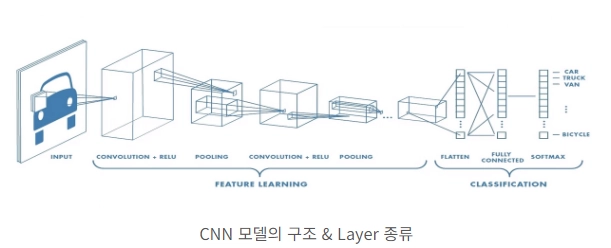

> CNN 모델은 위치 별 특징을 추출(Feature Learning)하는 부분과 클래스를 분류하는 부분(Classification)으로 나눌 수 있음

- **특징 추출(Feature learning) 영역:** **Convolution Layer**와 **Pooling Layer**를 여러 겹 쌓는 형태로 구성

    - Convolution Layer: 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소

    - Pooling Layer: Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 중요한 
    특징을 강조하는 역할. 모델의 계산 효율성을 높이고, 과적합을 방지하는 데 도움을 줌

- **이미지 분류(Classification)를 하는 영역:** CNN 모델의 마지막에 위치하고 Fully Connected Layer로 구성

##### CNN 은 크게 두 부분으로 나뉨

1. **특징 추출 (Feature Learning)** - **Convolution,** **Pooling**이 담당

2. **클래스 분류 (Classification)** - **Fully Connected Layer**가 담당

##### ***Convolution Layer***

> 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징을 학습

1. 필터(Filter) 또는 커널(Kernel)이 이미지 위를 슬라이딩

    - CNN 의 필터 값은 MLP 의 가중치(weight)와 같은 역할

2. 각 위치에서 요소별 곱셈 후 합계 계산

3. 결과를 Feature Map 에 저장

    - **feature map**: input data에 filter를 적용하여 얻은 결과물

    - feature map의 차원은 filter의 수에 따라 결정됨.

##### ***Padding***

> filter를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법

- padding=1로 설정했을 의 연산 과정

- padding을 적용하지 않은 경우 feature map의 크기는 2x2 → padding 적용시 4x4

=> 이미지 크기를 유지하면서 가장자리 특징까지 반영 가능

##### ***Stride(보폭)***

> 이미지를 몇 칸씩 점프하면서 훑을 것인지 결정하는 값

- **Stride = 1**: 한 칸씩 이동 (세밀한 특징 추출)

- **Stride = 2**: 두 칸씩 이동 (빠른 처리, 크기 축소)

→ 계산량 감소, 겹치는 영역을 줄여 효율적으로 요약
=> stride 가 커질 수록 feature map 의 크기 작아짐

##### ***Pooling***

> 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것

pooling 을 쓰지 않으면 :

00이 있다 (X)

00이 정확히 이 위치에 있다 (O)

=> 원래 있던 위치에 00이 없으면 00을 못 알아볼 수 있음

📌 Pooling 의 종류

* Max Pooling: **최댓값** 선택 (대부분의 경우 사용)

* Average Pooling: **평균값** 선택

| **장점** | **단점** |
| --- | --- |
| 차원을 축소시켜 모델 용량과 계산량이 감소 | 정보 소실의 위험이 있음 |
| 노이즈를 제거하고 중요한 데이터(피처)만 유지 |  |
| 불필요한 정보를 제거해 과적합 방지 |  |

📌 CNN 구조 정리

- **Convolution**과 **Pooling**을 이용해 특징 추출을 진행

- 연산 과정에서 출력(feature map)의 크기와 정보 보존 정도를 조절하기 위한 하이퍼파라미터로 padding, stride가 활용

#### 1-3 대표적인 CNN 아키텍쳐

##### AlexNet(2012) 
> : **머신러닝에서 벗어나 최초로 GPU를 이용해 학습한 대규모 CNN 모델**

- 5개의 Convolutional Layer + 3개의 Fully Connected Layers
    
    ⇒ 총 8층 구조
    
- 활성화 함수로 ReLU 함수를 이용해 **Vanishing gradient(기울기 소실) 문제 해소**
    - Sigmoid 보다 효율적인 학습 가능
- Dropout을 통한 **과적합 방지**

##### VGGNet(2014)
> : 이미지 인식에 강한 깊은 층의 CNN 모델

- Conv + Pool(max)을 여러번 반복
- filter 크기가 3x3으로 고정

- 단순하지만 층의 깊이를 늘려 정확도를 높임

- 이미 만들고 학습시킨 VGGNet 모델을 가져와 사용하는 **전이 학습**에 많이 쓰는 모델

- 초반 연산량이 매우 많음



##### ResNet(2015)

> 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결한 모델

- 잔차 연결 : 이전 레이어의 출력을 몇 레이어를 건너뛰고 다음 레이어의 입력으로 직접 추가하는 방식
    - 학습방식
        - 입력 x와 두 개의 내부 연산 결과 F(x)를 더한 것이 최종 출력, 즉 입력과 출력에 차이만 학습

        - 단: 입력과 출력의 차원을 맞춰야 함

- 층을 깊게 쌓아도(~152층) 기울기 소실 문제 없이 학습이 가능함

- 현재까지 많은 모델의 기반이 되는 구조

---

### 2. 이미지 딥러닝 응용

#### 2-1 이미지 분류(Image Classification)

> 이미지를 수치 데이터(픽셀 값)로 인식 → 사전 정의된 클래스 중 하나로 분류

| 모델명 | 특징 요약 | 주의사항 |
| --- | --- | --- |
| **AlexNet** | 비교적 단순한 구조, 초기 CNN 모델들 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| **VGG** | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
| **ResNet** | Residual 연결 (skip connections) → 매우 깊은 네트워크 가능 | 과적합 주의, batch size / regularization 조절 필요 |
| **Vision Transformer (ViT)** | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |

#### 2-2 객체 탐지(Object Detection)

> 객체 검출(object detection)은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업

- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올림:

    - Classification Head: 객체의 클래스 예측

    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측
    
- **대표 모델**: YOLO, Faster R-CNN, SSD 등

#### 2-3 이미지 캡셔닝(Image Captioning)

> image captioning은 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현


##### **📌 모델 적용방식: CNN과 RNN**

이미지 특징을 추출하기 위한 CNN과 문장으로 나타내기 위한 RNN

##### **📌 이미지 캡셔닝 단계**

* CNN 을 이용한 특징 추출

    - RGB 3채널의 인풋 데이터를 ResNet-101을 이용하여 특징 추출

* Attention Network 를 이용하여 단어 생성

    - Attention Network 를 통과하여 중요한 부분에 가중치를 두어 단어 추출

    - 가중치가 높은 부분을 이용해 사진을 한 문장으로 설명할 수 있게 함

* RNN 을 이용하여 문장 완성

    - 가중치를 바탕으로 추출해 낸 이미지의 주요 단어들을 RNN 을 통해 조합하여 문장 완성

---

### 3. 과거를 기억하는 신경망: RNN (Recurrent Neural Network)

#### 3-1 순차 데이터

> 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터

##### ***순차 데이터 예시***

1. 음성 및 오디오 데이터

    - 소리의 파형은 시간에 따라 연속적으로 변화하는 순차 데이터

2. 자연어

    - 문장, 단락, 문서 등 단어의 순서가 매우 중요한 대표적인 순차 데이터

3. 생물학적 서열 데이터

    - DNA, 단백질 서열처럼 특정 순서로 배열된 순차 데이터

4. 비디오 데이터

    - 여러 이미지 프레임이 순서대로 나열된 형태의 순차 데이터

##### ***기존 정형 데이터와의 차이점***

- 일반적인 정형 데이터의 특징

    - 샘플(행)의 독립성: 각 행은 독립적인 정보를 나타내므로, 행의 순서가 바뀌어도 데이터셋의 의미가 변하지 않음

    - 특성(열) 순서의 독립성: ‘나이, 키’ 순서로 데이터를 분석하든, ‘키, 나이’ 순서로 분석하든, 각 특성이 담고 있는 정보는 동일

- 순차 데이터의 특징

    - **요소의 순서 의존성**: 데이터를 구성하는 요소들의 순서 자체가 핵심 정보

    - **자기상관성**: 이전 시점의 데이터가 다음 시점의 데이터에 영향을 미침


⇒ 순차 데이터 이러한 특징을 고려하기 위해서는 기존의 머신러닝 기법으로는 한계가 있음

**⇒ 과거의 정보를 기억하고, 순서의 의미를 학습할 수 있는 특별한 신경망이 필요함**

#### 3-2 RNN 의 구조와 원리

> 순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망

##### ***RNN 의 구조***

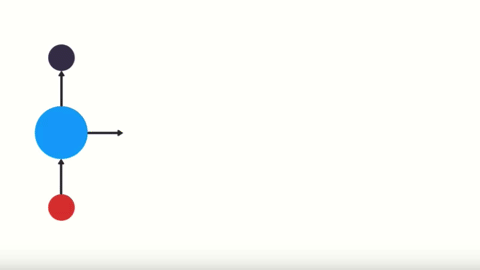
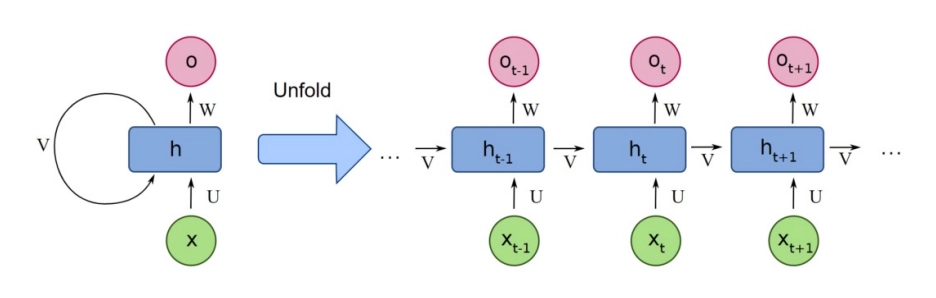

- 초록색은 **입력층**, 파란색은 **은닉층**, 분홍색은 **출력층**을 의미
- **용어 설명**
    - $x_t$: 시간  $t$에서의 **입력 (Input)**
    - $h_t$: 시간  $t$에서의 **은닉 상태 (Hidden State)**. 이 시점의 '**메모리**'
    - $o_t$: 시간  $t$에서의 **출력 (Output)**
    - $U$(**입력 가중치**):
        - 현재 시점  $t$의 입력($x_t$)이 은닉 상태($h_t$)에 영향을 주는 가중치
    - $V$(**순환 가중치**):
        - 이전 시점 $t-1$의 은닉 상태($h_{t-1}$)가 현재 은닉 상태에 영향을 주는 가중치
    - $W$(**출력 가중치**):
        - 현재 시점 $t$의 은닉 상태($h_{t}$)가 최종 출력($o_t$)에 영향을 미치는 가중치
        - 계산된 메모리를 바탕으로 **결과**를 만들어내는 역할
    - 기존 신경망과의 차이점
        - **V(순환 가중치)의 유무**
        
        우리가 기존에 배웠던 신경망의 이미지를 생각해 보면, 위 이미지에서의 V, 순환 가중치가 존재하지 않음
        즉, 입력층에서 은닉층을 거쳐 바로 출력층으로 이동
        
        하지만 RNN에서는 V(순환 가중치)를 통해 이전 시점의 정보를 전달
        위에서 적은 RNN을 뉴런 단위로 시각화하면 다음과 같음
        
        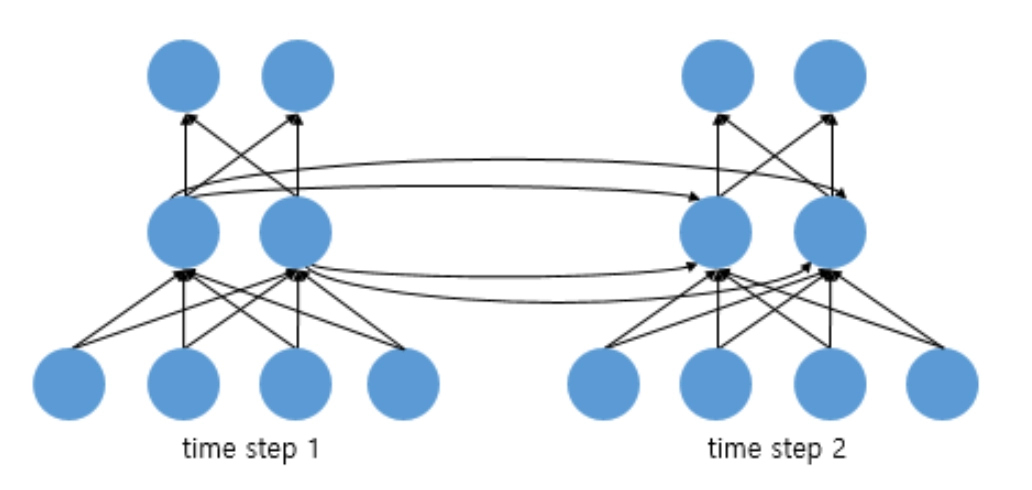
        
         - 기존 DNN(Deep Neural Network)에는 저 사이를 연결해주는 선이 없었음
    
    - **정보 흐름**
    - **$t−1$  시점**: 입력 $x_{t-1}$이 들어가서 은닉 상태 $h_{t-1}$을 업데이트하고, 출력 $o_{t-1}$을 내보냅니다.
    - **$t$  시점**:  $t−1$ 시점에서 계산된 **은닉 상태 $h_{t-1}$이 다음 시점으로 그대로 전달**됩니다.
    - **새로운 입력** $x_t$와 전달받은 **과거 정보** $h_{t-1}$을 함께 사용하여 **현재 시점의 은닉 상태** $ht$를 업데이트하고, **출력** $o_t$를 계산합니다.

    **⇒ 은닉 상태(Hidden State)의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달**


##### ***RNN 의 핵심원리 : 가중치 공유***

- **동일한 가중치**를 시퀀스의 다양한 시점에서 **반복**적으로 적용

- RNN이 시퀀스 데이터의 **길이와 시점 위치에 상관없이** 효과적으로 작동하게 하는 핵심 원리

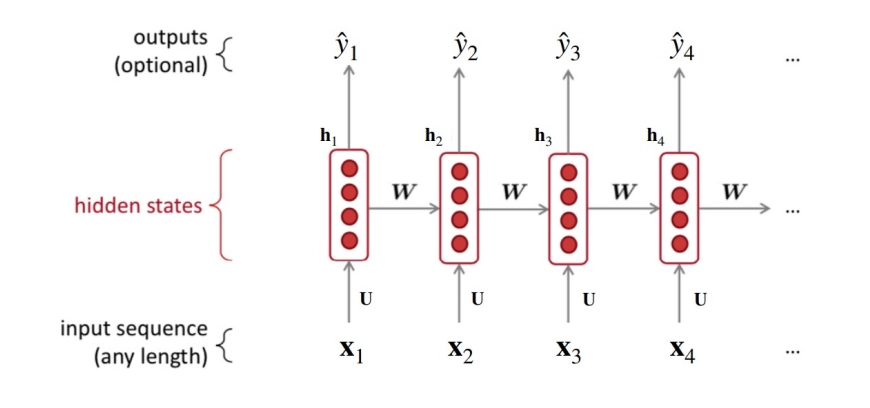
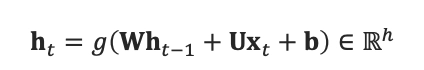

$X_1$을 처리할 때, $X_2$를 처리할 때, 그리고 $X_n$을 처리할 때까지 모두 동일한 파라미터(입력 가중치(U), 순환 가중치(W), 편향(b)) 를 공유하는 구조

##### 📌 가중치 공유의 이점

- **학습 파라미터의 수 감소**
    - 가중치 공유를 통해 RNN은 입력 시퀀스의 길이가 아무리 길어져도 **학습해야 할 파라미터의 수가 일정하게 유지된다.**
        
    ⇒ 모델을 더 빠르고 가볍게 만듦
        
- **일반화 능력 향상**

    - RNN은 “**이전 시점까지의 정보**와 **현재 시점의 입력**이 주어졌을 때, 어떻게 **상태(메모리)를 업데이트할 것인가?**”라는 **하나의 일반적 규칙**을 학습

        - ‘세 번째 데이터를 처리하는 규칙’, ‘다섯 번째 데이터를 처리하는 규칙’을 **각각 따로 배우는 것이 아니다.**

    - 훈련 데이터에 없던 **새로운 길이**의 시퀀스나 **다양한 패턴**에도 **유연하게 대응** 가능하다.

#### 3-3 RNN 의 한계 및 장기 의존성 문제(The Long-Term Dependency Problem)

##### ***RNN 의 한계***

* RNN 구조의 특성 상 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐

    - 역전파를 구하는 과정에서 chain rule 에 의해 다음 미분값이 반복적으로 곱해짐(등비수열 형태)

    $$
    \frac{\partial h_t}{\partial h_{t-1}} = \underbrace{\text{diag}\left(g'(a_t)\right)}_{\text{활성화 함수 미분값}} \ \times\underbrace{W_{hh}}_{\text{순환 가중치}}
    $$

    - $\text{diag}(g'(a_t))$

        - $g(a_t)$는 RNN에서 사용하는 활성화 함수

        - $g'(a_t)$는 그 함수의 미분값(기울기)

        - $\text{diag}(g'(a_t))$는 각 뉴런의 미분값을 대각행렬로 표현한 것

            - 각 hidden unit이 독립적으로 작용한다는 의미

    - $W_{hh}$

        - 정보가 어디에서 와서 어디로 가는가를 명확하게 나타내는 표기법

        - hidden state에서 hidden state로 정보가 전달될 때 사용되는 가중치라는 뜻

            - 첫 번째 h: 출발지 → 이전 시점의 은닉 상태 ($h_{t-1}$)

            - 두 번째 h: 도착지 → 현재 시점의 은닉 상태 ($h_t$)

* 기울기 소실(Vanishing Gradients)

    - 시퀀드 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상

    - 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 작을 때 => 기울기가 0으로 수렴

* 기울기 폭주(Exploding Gradients)

    - 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제

    - 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 클 때 => 기울기가 무한대로 발산

* 느린 훈련 시간

    - 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계

    - $t$ 시점의 은닉 상태($h_t$)를 계산하려면 $t-1$ 시점의 은닉 상태($h_{t-1}$)가 먼저 계산되어야 함 => 이 의존성 떄문에 전체 시퀀스를 한 번에 병렬 처리 불가능

##### ***장기 의존성 문제(Long-Term Dependency Problem)***

* 위 세가지 RNN 의 구조적 한계는 **장기 의존성 문제**라는 하나의 치명적인 약점으로 이어짐

* 시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상

* 모델의 '단기 기억력'은 준수했지만, **장기 기억력**에 문제 발생

=> 새로운 모델이 필요하다

- RNN 의 기억력 한계 극복

- 더 길고 복잡한 시퀀스 데이터를 안정적으로 다룰 수 있는 새로운 대안

- 중요한 정보는 오래 기억하고, 불필요한 정보는 잊는 똑똑한 메모리 구조

---

### 4. 똑똑하게 기억하고 잊는 법: LSTM &GRU

#### LSTM

* 셀 상태 $C_t$ - 장기 기억): 이 기억은 절대 변하지 않는 핵심 기억

* 엘리트 (은닉 상태 $h_t$ - 단기 기억/출력):  현재 상황에서 바로 사용하는 기억. 셀 상태에서 필요한 정보만 꺼내서, 지금 시점에서의 판단이나 출력으로 사용

* 장기기억과 단기기억 및 출력을 따로 분리해서 관리

#### GRU

* 모든 기억과 행동이 하나의 상태($h_t$)로 통합되어 있음

* LSTM 에 비해 단순하지만 정교함이 떨어짐


#### 4-1 게이트(Gate)로 정보의 흐름을 제어하다 : LSTM

> 기억할 내용과 잊어버릴 내용을 선택해서, 중요한 정보들을 오래 가져감 -> **GATE**를 통해 곱셈을 덧셈으로 바꾼다

* RNN 과의 주요 차이 : $c_t\text{와}\space h_t$의 2개의 순환되는 층을 사용

    - $c_t$(cell state): 장기 기억
    
    - $h_t$(hidden state): 단기 기억

* **Gate를 통해 필요한 정보들만 통과** 

    - Forget gate: 정보를 **얼마나 잊어**버릴지 결정

    - Input gate: 현재 정보를 **얼마나 사용**할지 결정

    - Output gate: 다음 층으로 **어떤 정보를 전달**할지 결정 (hidden state를 만듦)

* Final memory cell: Input, forget gate를 결합해 현재 정보를 얼마나 기억할지 계산

* 장점 : Vanishing gradient problem 효과적으로 완화 (≠해결)

    - Gate를 통해 기억할 정보와 잊을 정보를 나눠서 관리함으로써, 이전의 정보가 중요하게 판단된다면, 완전히 보존되는 상태로 hidden state를 갱신해나갈 수 있기 때문

* 단점: (많이) 복잡한 구조, RNN보다 학습 파라미터가 많아짐

#### 4-2 더 단순하고 효율적인 구조 : GRU(Gated Recurrent Unit)

* LSTM 과의 차이점 

    - Forget gate와 input gate를 **update gate 하나로 합침**
    
    - **Reset gate를 사용**
    
    - **Gate의 개수가 3개에서 2개로** 줄어 학습 시간이 줄어듦
    
    → 학습 시간은 줄어들지만 성능은 LSTM과 유사하거나 더 좋음

* 장점 : 성능과 효율성 사이의 균형이 좋음

* 단점: 긴 시퀀스 처리에서의 한계는 여전히 존재

#### 4-3 LSTM vs GRU 

| 구분 | LSTM | GRU |
| --- | --- | --- |
| **구조** | 3개 게이트 (입력, 삭제, 출력) | 2개 게이트 (업데이트, 리셋) |
| **복잡도** | 더 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음 |
| **학습 속도** | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| **메모리 사용량** | 큼 | 작음 |
| **장기 의존성 처리** | 더 강력 | LSTM과 비교해 다소 약함 |
| **연구/사례 축적** | 매우 많음 | 비교적 적음 (최근 등장) |
| **성능** | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |

- **LSTM 적합한 경우**

    - 긴 시퀀스에서 문맥 이해가 중요한 작업

    - 데이터 양이 충분하고 복잡한 패턴을 학습해야 하는 경우

    - 모델 성능이 계산 효율보다 더 중요한 경우

    - 기계 번역, 언어 모델링, 장기 시계열 예측 (예: 금융, 기후 데이터)

- **GRU 적합한 경우**

    - 자원이 제한적이거나 학습 속도가 중요한 경우

    - 데이터 양이 적고 과적합 위험이 있는 경우
    
    - 실시간 예측이 필요한 응용

    - 사용 예시: 음성 인식, 스트리밍 데이터, 실시간 비디오 분석, 짧은 시퀀스 기반의 텍스트 분류

---

### 5. 문장을 입력받아 문장을 출력하다 : Seq2Seq

> 한 시퀀스를 다른 시퀀스로 변환하는 작업ㅇ르 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용됨

* 아이템(단어)의 입력 개수와 출력 개수가 같지 않아도 됨

* 인코더와 디코더라는 모듈을 가지고 있어, Encoder-Decoder 모델이라고도 불림

    - 인코더(Encoder) : 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비(원문의 특징 파악)

        -> 압축된 정보 = 컨텍스트 벡터(context vector)

        - 인코더에서는 t 시점의 임베딩된 단어의 입력과 t-1 시점의 은닉 상태(hidden state)가 RNN/LSTM의 입력으로 주어지며, 그 결과로 t시점의 은닉 상태가 나옴

    - 디코더(Decoder) : 압축된 정보를 바탕으로 원하는 시퀀스를 생성(번역문 생성)

        - 기본적으로 인코더가 보내준 컨텍스트 벡터는 디코더의 첫번쨰 은닉 상태에 사용됨

        - t 시점에 나온 출력값이 그 다음 시점의 입력값으로 넘어감
    
    - 인코더와 디코더 모두 그림과 같이 RNN(LSTM,GRU) 를 여러개 조합한 형태

    - 모든 단어는 워드 임베딩(word2vec) 과정을 거침

    - 컨텍스트 백터 : float 형의 벡터 형태로 인코더 중 마지막 시점의 은닉 상태(hidden state) 의미

        - 입력 시퀀스(입력된 문장)의 요약 정보처럼 작동

        - 벡터의 차원은 직접 설정 가능

#### ***seq2Seq 의 한계 : 병목 현상(Bottleneck)***

> 길이기 긴 문장을 요약할 수 있는 요약본의 크기에 제한이 생기면 원래 문장의 정보가 손실될 수 있음 => 고정된 컨텍스트 벡터에 소스 문장의 정보 압축 -> 병목 현상 발생

**(추가)** 기울기 소실 문제 발생, 병렬화 불가